## Dataset Link
https://www.kaggle.com/datasets/kazanova/sentiment140

## Research Question

How accurately can we classify the sentiment of tweets using traditional ML models in a PySpark environment?

## Import Required Libraries

In [245]:
from pyspark.sql import SparkSession
from pyspark import SparkConf
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.classification import LinearSVC
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import when, col , regexp_replace, lower, trim
import xgboost as xgb
from pyspark.ml import Estimator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from concurrent.futures import ThreadPoolExecutor
import pandas as pd


In [246]:
spark = SparkSession.builder.appName('SentimentAnalysis').master('local[*]').config("spark.local.dir", r"C:\Users\Laptop\Desktop\BDP New Project\temp")\
    .config("spark.sql.warehouse.dir", r"C:\Users\Laptop\Desktop\BDP New Project\temp").config("spark.executor.memory", "12g")\
    .config("spark.driver.memory", "12g").config("spark.executor.cores", "6").config("spark.driver.cores", "6").getOrCreate()

## Loading the CSV file

In [247]:

data_path = r'C:\Users\Laptop\Desktop\BDP New Project\training.1600000.processed.noemoticon.csv'
tweets_df = spark.read.csv(data_path, header=False, inferSchema=True)

tweets_df.show(5)

+---+----------+--------------------+--------+---------------+--------------------+
|_c0|       _c1|                 _c2|     _c3|            _c4|                 _c5|
+---+----------+--------------------+--------+---------------+--------------------+
|  0|1467810369|Mon Apr 06 22:19:...|NO_QUERY|_TheSpecialOne_|@switchfoot http:...|
|  0|1467810672|Mon Apr 06 22:19:...|NO_QUERY|  scotthamilton|is upset that he ...|
|  0|1467810917|Mon Apr 06 22:19:...|NO_QUERY|       mattycus|@Kenichan I dived...|
|  0|1467811184|Mon Apr 06 22:19:...|NO_QUERY|        ElleCTF|my whole body fee...|
|  0|1467811193|Mon Apr 06 22:19:...|NO_QUERY|         Karoli|@nationwideclass ...|
+---+----------+--------------------+--------+---------------+--------------------+
only showing top 5 rows



In [248]:
tweets_df = tweets_df.toDF('target', 'id', 'datetime', 'flag', 'user', 'text')
tweets_df.show(5)

+------+----------+--------------------+--------+---------------+--------------------+
|target|        id|            datetime|    flag|           user|                text|
+------+----------+--------------------+--------+---------------+--------------------+
|     0|1467810369|Mon Apr 06 22:19:...|NO_QUERY|_TheSpecialOne_|@switchfoot http:...|
|     0|1467810672|Mon Apr 06 22:19:...|NO_QUERY|  scotthamilton|is upset that he ...|
|     0|1467810917|Mon Apr 06 22:19:...|NO_QUERY|       mattycus|@Kenichan I dived...|
|     0|1467811184|Mon Apr 06 22:19:...|NO_QUERY|        ElleCTF|my whole body fee...|
|     0|1467811193|Mon Apr 06 22:19:...|NO_QUERY|         Karoli|@nationwideclass ...|
+------+----------+--------------------+--------+---------------+--------------------+
only showing top 5 rows



In [249]:
tweets_df.select('target').distinct().show()

+------+
|target|
+------+
|     0|
|     4|
+------+



## Data Preprocessing

In [250]:
# 0 is for neg, 4 is for positive in target column, Replacing 4 with 1 to avoid csv error 
tweets_df = tweets_df.withColumn('target', when(col('target') == 4, 1).otherwise(col('target')))
tweets_df.select('target').distinct().show()

+------+
|target|
+------+
|     0|
|     1|
+------+



In [251]:
tweets_df.groupBy('target').count().show()

+------+------+
|target| count|
+------+------+
|     0|800000|
|     1|800000|
+------+------+



In [252]:
# We are only going to analyze tweet and sentiment(target refers as positive(1), neg (0))
tweets_df = tweets_df[['target', 'text']]
tweets_df

DataFrame[target: int, text: string]

In [253]:
print(tweets_df.columns)

['target', 'text']


In [254]:
# getting a managable data length to mininmize computauion overhead and time, 20K rows of pos and 20K rows of neg tweets

fractions = {0: 20000 / tweets_df.filter(tweets_df["target"] == 0).count(),
             1: 20000 / tweets_df.filter(tweets_df["target"] == 1).count()}
sampled_df = tweets_df.sampleBy("target", fractions=fractions, seed=0)

sampled_df.groupBy("target").count().show()

+------+-----+
|target|count|
+------+-----+
|     0|19887|
|     1|19878|
+------+-----+



## Data Cleaning

In [255]:

def clean_text(df):

    df = df.select(label_col, text_col).na.drop(subset=[text_col])
    df = df.withColumn(text_col, regexp_replace(col(text_col), r'http\S+|www\.\S+', ''))
    df = df.withColumn(text_col, regexp_replace(col(text_col), r'@\w+|#', ''))
    df = df.withColumn(text_col, regexp_replace(col(text_col), r'[^a-zA-Z\s]', ''))
    df = df.withColumn(text_col, lower(col(text_col)))
    df = df.withColumn(text_col, trim(col(text_col)))
    df = df.filter(col(text_col).rlike(r'\S'))
    return df

data_df = clean_text(sampled_df)

data_df.show(5)


+------+--------------------+
|target|                text|
+------+--------------------+
|     0|        que me muera|
|     0|and india missed ...|
|     0|crazy wind today ...|
|     0|i hate to see the...|
|     0|feeling lost nake...|
+------+--------------------+
only showing top 5 rows



## Tokenization and Stop Word Removal

In [257]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover

def tokenize_and_remove_stopwords(data_df):
    
    tokenizer = Tokenizer(inputCol='text', outputCol='tokenized_text_new')
    tokenized_df = tokenizer.transform(data_df)

    remover = StopWordsRemover(inputCol='tokenized_text_new', outputCol='filtered_words_new')
    filtered_df = remover.transform(tokenized_df)

    return filtered_df

filtered_df = tokenize_and_remove_stopwords(data_df)
filtered_df.select('text', 'filtered_words_new').show(5)


+--------------------+--------------------+
|                text|  filtered_words_new|
+--------------------+--------------------+
|        que me muera|        [que, muera]|
|and india missed ...|[india, missed, t...|
|crazy wind today ...|[crazy, wind, tod...|
|i hate to see the...|[hate, see, spart...|
|feeling lost nake...|[feeling, lost, n...|
+--------------------+--------------------+
only showing top 5 rows



## Feature Extraction (TF-IDF for PySpark models)

In [259]:
from pyspark.ml.feature import HashingTF, IDF

def extract_features_tfidf(filtered_df):
    hashingTF = HashingTF(inputCol='filtered_words_new', outputCol='rawFeatures_new', numFeatures=10000)
    tf_df = hashingTF.transform(filtered_df)

    idf = IDF(inputCol='rawFeatures_new', outputCol='features_new')
    idf_model = idf.fit(tf_df)
    final_df = idf_model.transform(tf_df)

    return final_df

final_df = extract_features_tfidf(filtered_df)


In [260]:
# columns in your DataFrame
print(final_df.columns)
final_df.show(5)

['target', 'text', 'tokenized_text_new', 'filtered_words_new', 'rawFeatures_new', 'features_new']
+------+--------------------+--------------------+--------------------+--------------------+--------------------+
|target|                text|  tokenized_text_new|  filtered_words_new|     rawFeatures_new|        features_new|
+------+--------------------+--------------------+--------------------+--------------------+--------------------+
|     0|        que me muera|    [que, me, muera]|        [que, muera]|(10000,[4487,9067...|(10000,[4487,9067...|
|     0|and india missed ...|[and, india, miss...|[india, missed, t...|(10000,[208,740,2...|(10000,[208,740,2...|
|     0|crazy wind today ...|[crazy, wind, tod...|[crazy, wind, tod...|(10000,[775,2144,...|(10000,[775,2144,...|
|     0|i hate to see the...|[i, hate, to, see...|[hate, see, spart...|(10000,[2069,3609...|(10000,[2069,3609...|
|     0|feeling lost nake...|[feeling, lost, n...|[feeling, lost, n...|(10000,[613,1233,...|(10000,[613,

## Train Test Split

In [261]:
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

train_df = train_df.cache()
test_df = test_df.cache()

print(f'Training examples: {train_df.count()}, Testing examples: {test_df.count()}')

train_df.unpersist()
test_df.unpersist()


Training examples: 31867, Testing examples: 7804


DataFrame[target: int, text: string, tokenized_text_new: array<string>, filtered_words_new: array<string>, rawFeatures_new: vector, features_new: vector]

##  Model Definition (Logistic Regression, SVM, Random Forest, Decision Tree, Naive Bayes, Gradient Boost)

In [262]:
from pyspark.ml.classification import LogisticRegression, LinearSVC, RandomForestClassifier, DecisionTreeClassifier, NaiveBayes, GBTClassifier
from pyspark.ml import Pipeline



In [263]:
# Model Definitions

lr  = LogisticRegression(labelCol='target', featuresCol='features_new')
svm = LinearSVC(labelCol='target', featuresCol='features_new')
nb  = NaiveBayes(labelCol='target', featuresCol='features_new', modelType="multinomial")
rf  = RandomForestClassifier(labelCol='target', featuresCol='features_new')
dt  = DecisionTreeClassifier(labelCol='target', featuresCol='features_new')
gbt = GBTClassifier(labelCol='target', featuresCol='features_new')

# Pipelines Definitions
lr_pipeline  = Pipeline(stages=[lr])
svm_pipeline = Pipeline(stages=[svm])
nb_pipeline  = Pipeline(stages=[nb])
rf_pipeline  = Pipeline(stages=[rf])
dt_pipeline  = Pipeline(stages=[dt])
gbt_pipeline = Pipeline(stages=[gbt])



## Training Models with Multithreading 

In [264]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

In [265]:


def train_model_in_thread(train_df, pipeline, model_name, backend='spark'):
    print(f"Training {model_name} on {backend}...")
    model = pipeline.fit(train_df)
    print(f"{model_name} training complete.")
    return model

# Threading.....
def train_models_parallel(train_df):
    with ThreadPoolExecutor(max_workers=6) as executor:
        futures = {
            executor.submit(train_model_in_thread, train_df, lr_pipeline, 'Logistic Regression', 'spark'): 'lr',
            executor.submit(train_model_in_thread, train_df, svm_pipeline, 'SVM', 'spark'): 'svm',
            executor.submit(train_model_in_thread, train_df, nb_pipeline, 'Naive Bayes', 'spark'): 'nb',
            executor.submit(train_model_in_thread, train_df, rf_pipeline, 'Random Forest', 'spark'): 'rf',
            executor.submit(train_model_in_thread, train_df, dt_pipeline, 'Decision Tree', 'spark'): 'dt',
            executor.submit(train_model_in_thread, train_df, gbt_pipeline, 'Gradient Boosting', 'spark'): 'gbt'
        }

        trained_models = {}
        for future in tqdm(futures, total=len(futures), desc="Training Models"):
            model_key = futures[future]
            trained_models[model_key] = future.result()
    return trained_models


##  Model Evaluation

In [266]:

def evaluate_models(models, test_df):
    evaluator_acc = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="accuracy")
    evaluator_precision = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="precisionByLabel")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="recallByLabel")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="f1")

    results = []
    model_name_map = {"lr": "Logistic Regression",
        "svm": "SVM",
        "nb": "Naive Bayes",
        "rf": "Random Forest",
        "dt": "Decision Tree",
        "gbt": "Gradient Boosting"}

    for name, model in models.items():
        if hasattr(model, "bestModel"):
            final_model = model.bestModel
        else:
            final_model = model
        preds = final_model.transform(test_df)

        # Accuracy
        acc = evaluator_acc.evaluate(preds)

        prec_0 = evaluator_precision.evaluate(preds, {evaluator_precision.metricLabel: 0})
        rec_0 = evaluator_recall.evaluate(preds, {evaluator_recall.metricLabel: 0})
        f1_0 = evaluator_f1.evaluate(preds, {evaluator_f1.metricLabel: 0})
        prec_1 = evaluator_precision.evaluate(preds, {evaluator_precision.metricLabel: 1})
        rec_1 = evaluator_recall.evaluate(preds, {evaluator_recall.metricLabel: 1})
        f1_1 = evaluator_f1.evaluate(preds, {evaluator_f1.metricLabel: 1})

        # Confusion Matrix 
        conf_df = preds.groupBy("target", "prediction").count().toPandas()

        def get_count(df, actual, predicted):
            match = df[(df["target"] == actual) & (df["prediction"] == predicted)]
            return int(match["count"].values[0]) if not match.empty else 0

        TN = get_count(conf_df, 0, 0)
        FP = get_count(conf_df, 0, 1)
        FN = get_count(conf_df, 1, 0)
        TP = get_count(conf_df, 1, 1)

        results.append({"Model": model_name_map.get(name, name),
            "Accuracy": acc,
            "Precision Class 0": prec_0,
            "Recall Class 0": rec_0,
            "F1-Score Class 0": f1_0,
            "Precision Class 1": prec_1,
            "Recall Class 1": rec_1,
            "F1-Score Class 1": f1_1,
            "Confusion Matrix (0, 0)": TN,
            "Confusion Matrix (0, 1)": FP,
            "Confusion Matrix (1, 0)": FN,
            "Confusion Matrix (1, 1)": TP})

    return pd.DataFrame(results)


## Plotting the results

In [267]:

def plot_results(results_df, title_prefix=""):
    sns.set(style="whitegrid")
    ## Accuracy 
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Model', y='Accuracy', data=results_df, color='black')
    plt.title(f'{title_prefix} Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    
    ## F1 Score
    plt.figure(figsize=(10, 5))
    sns.lineplot(x='Model', y='F1-Score Class 0', data=results_df,marker='o', label='F1 Score - Class 0', linestyle='--', color='black')
    sns.lineplot(x='Model', y='F1-Score Class 1', data=results_df, marker='o', label='F1 Score - Class 1', linestyle='-', color='orange')
    plt.title(f'{title_prefix} F1-Score Comparison')
    plt.ylabel('F1 Score')
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

    ## Confusion Matrix 
    plt.figure(figsize=(12, 6))
    models = results_df['Model']
    TN = results_df['Confusion Matrix (0, 0)']
    FP = results_df['Confusion Matrix (0, 1)']
    FN = results_df['Confusion Matrix (1, 0)']
    TP = results_df['Confusion Matrix (1, 1)']
    plt.bar(models, TN, color='blue', label='True Negative')
    plt.bar(models, FP, bottom=TN, color='red', label='False Positive')
    plt.bar(models, FN, bottom=TN + FP, color='yellow', label='False Negative')
    plt.bar(models, TP, bottom=TN + FP + FN, color='green', label='True Positive')
    plt.title(f'{title_prefix} Confusion Matrix Breakdown')
    plt.ylabel('Sample Count')
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()


Training Logistic Regression on spark...
Training SVM on spark...
Training Naive Bayes on spark...
Training Random Forest on spark...
Training Decision Tree on spark...
Training Gradient Boosting on spark...


Training Models:   0%|          | 0/6 [00:00<?, ?it/s]

Naive Bayes training complete.
Decision Tree training complete.
Random Forest training complete.


Training Models:  17%|█▋        | 1/6 [02:22<11:53, 142.64s/it]

Logistic Regression training complete.


Training Models:  33%|███▎      | 2/6 [03:31<06:38, 99.52s/it] 

SVM training complete.


Training Models: 100%|██████████| 6/6 [03:46<00:00, 37.69s/it]

Gradient Boosting training complete.


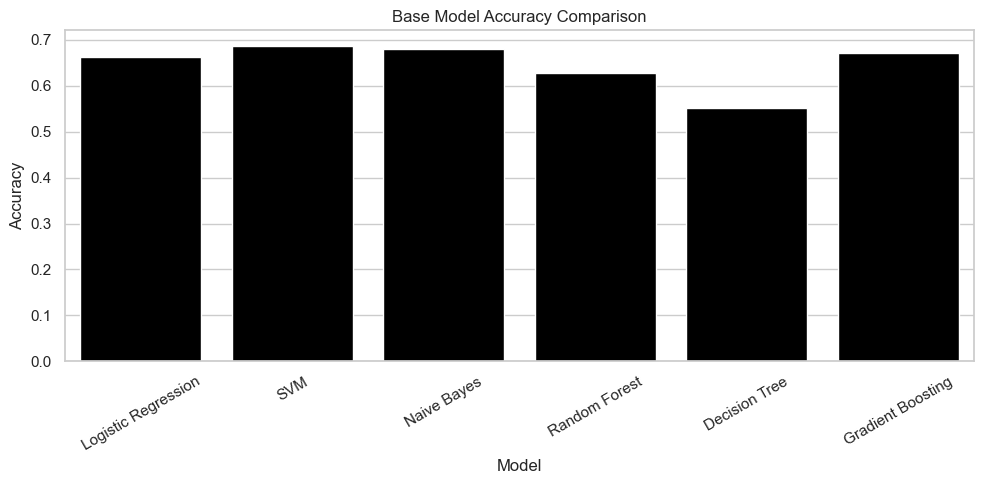

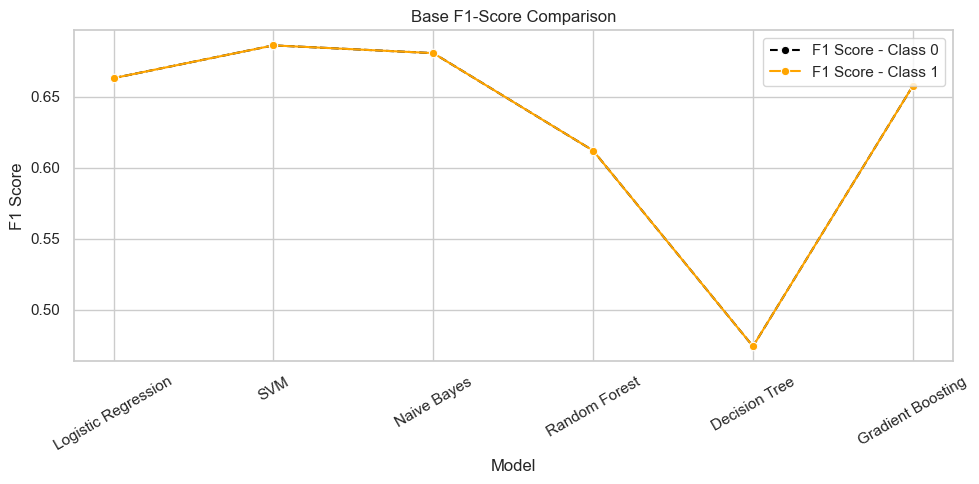

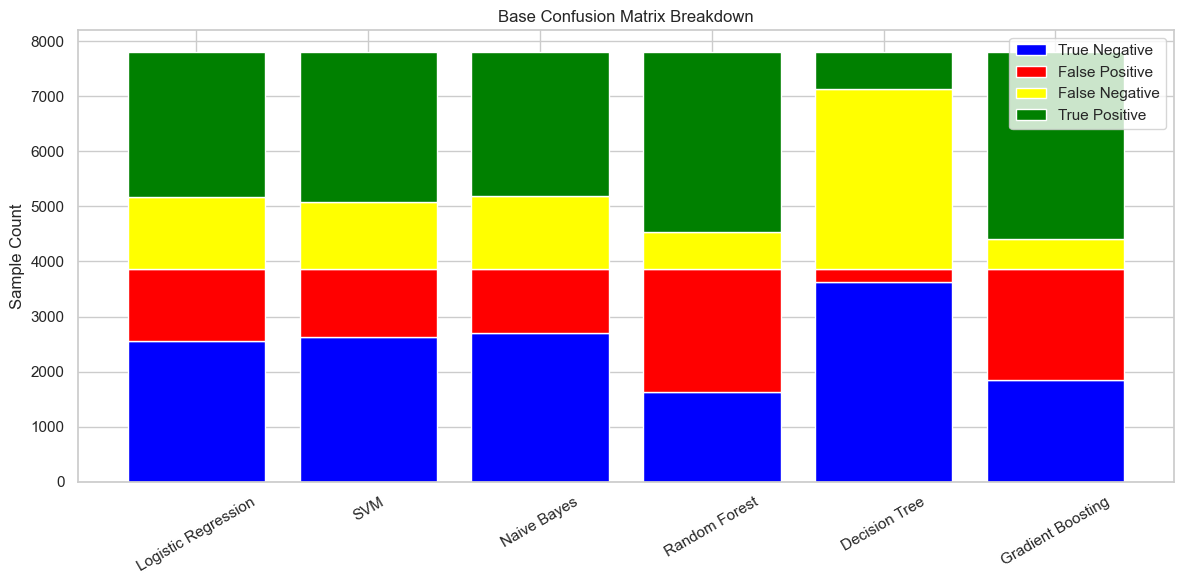

Base model results:
                  Model  Accuracy  Precision Class 0  Recall Class 0  \
0  Logistic Regression  0.662993           0.659508        0.659850   
1                  SVM  0.686058           0.683268        0.681853   
2          Naive Bayes  0.680677           0.670141        0.698939   
3        Random Forest  0.628011           0.707254        0.424023   
4        Decision Tree  0.551640           0.526362        0.940720   
5    Gradient Boosting  0.670297           0.769199        0.477090   

   F1-Score Class 0  Precision Class 1  Recall Class 1  F1-Score Class 1  \
0          0.662994           0.666413        0.666075          0.662994   
1          0.686055           0.688782        0.690180          0.686055   
2          0.680600           0.691921        0.662776          0.680600   
3          0.611961           0.594570        0.827962          0.611961   
4          0.474132           0.745556        0.170261          0.474132   
5          0.657527      

In [268]:
# Train base models
trained_models = train_models_parallel(train_df)
base_results_df = evaluate_models(trained_models, test_df)
plot_results(base_results_df, title_prefix="Base")
print("Base model results:\n", base_results_df)

## Hyper Parameter Tuning

Tuning lr>>>
LR tuning complete.

Tuning svm>>>
SVM tuning complete.

Tuning nb>>>
NB tuning complete.

Tuning rf>>>
RF tuning complete.

Tuning dt>>>
DT tuning complete.

Tuning gbt>>>
GBT tuning complete.



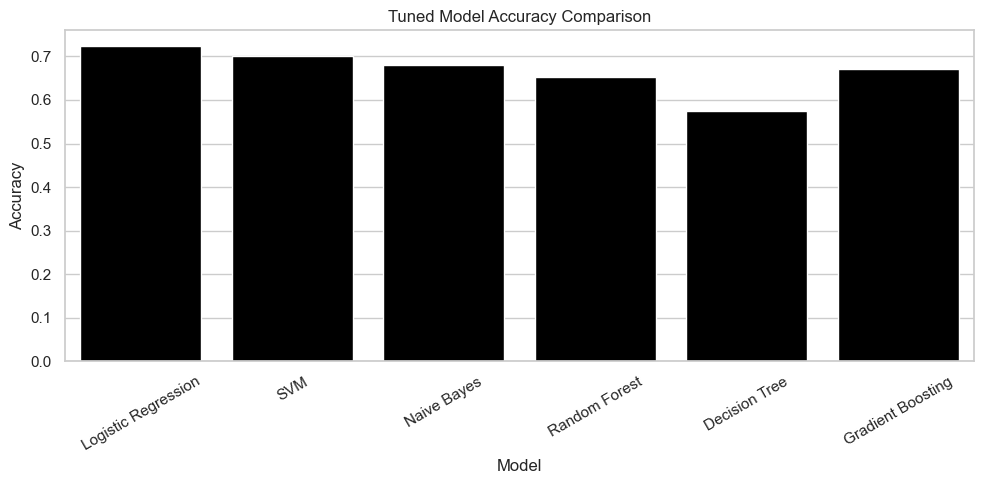

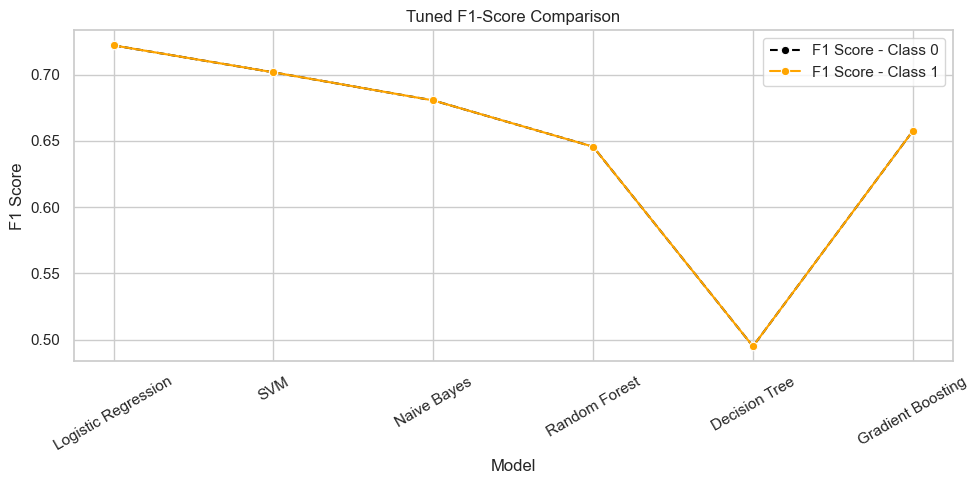

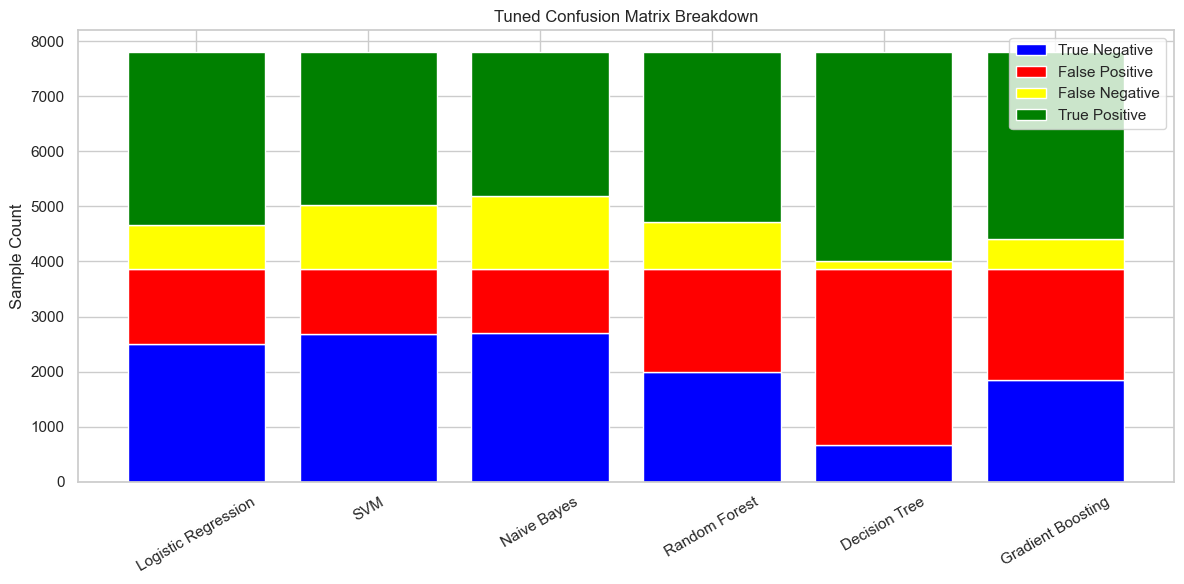

Tuned model results:
                  Model  Accuracy  Precision Class 0  Recall Class 0  \
0  Logistic Regression  0.723731           0.757621        0.649754   
1                  SVM  0.701820           0.699792        0.696350   
2          Naive Bayes  0.680677           0.670141        0.698939   
3        Random Forest  0.652101           0.701404        0.517473   
4        Decision Tree  0.574193           0.830882        0.175511   
5    Gradient Boosting  0.670297           0.769199        0.477090   

   F1-Score Class 0  Precision Class 1  Recall Class 1  F1-Score Class 1  \
0          0.722154           0.698731        0.796245          0.722154   
1          0.701811           0.703788        0.707181          0.701811   
2          0.680600           0.691921        0.662776          0.680600   
3          0.645662           0.623738        0.784065          0.645662   
4          0.494906           0.544219        0.964984          0.494906   
5          0.657527     

In [269]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

lr = LogisticRegression(labelCol="target", featuresCol="features_new")
svm = LinearSVC(labelCol="target", featuresCol="features_new")
nb = NaiveBayes(labelCol="target", featuresCol="features_new")
rf = RandomForestClassifier(labelCol="target", featuresCol="features_new")
dt = DecisionTreeClassifier(labelCol="target", featuresCol="features_new")
gbt = GBTClassifier(labelCol="target", featuresCol="features_new")

pipelines_dict = {"lr": Pipeline(stages=[lr]),
    "svm": Pipeline(stages=[svm]),
    "nb": Pipeline(stages=[nb]),
    "rf": Pipeline(stages=[rf]),
    "dt": Pipeline(stages=[dt]),
    "gbt": Pipeline(stages=[gbt])}

tuning_configs_dict = {'lr': [(lr.regParam, [0.01, 0.1]),(lr.elasticNetParam, [0.0, 0.5]),(lr.maxIter, [50])],
    'svm': [(svm.regParam, [0.01, 0.1]),(svm.maxIter, [50]),(svm.tol, [1e-4])],
    'nb': [(nb.smoothing, [0.5, 1.0])],
    'rf': [(rf.numTrees, [20]),(rf.maxDepth, [5, 10])],
    'dt': [(dt.maxDepth, [5, 10]),(dt.minInstancesPerNode, [1])],
    'gbt': [(gbt.maxIter, [10, 20]),(gbt.maxDepth, [5])]}

def tune_models(models_dict, tuning_params, train_df):
    evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
    tuned_models = {}
    for name, model in models_dict.items():
        param_grid = ParamGridBuilder()
        for param, values in tuning_params[name]:
            param_grid = param_grid.addGrid(param, values)

        crossval = CrossValidator(estimator=model,estimatorParamMaps=param_grid.build(),evaluator=evaluator, numFolds=3,parallelism=4)
        print(f"Tuning {name}>>>")
        tuned_model = crossval.fit(train_df)
        tuned_models[name] = tuned_model
        print(f"{name.upper()} tuning complete.\n")

    return tuned_models

tuned_models = tune_models(pipelines_dict, tuning_configs_dict, train_df)
tuned_results_df = evaluate_models(tuned_models, test_df)
plot_results(tuned_results_df, title_prefix="Tuned")
print("Tuned model results:\n", tuned_results_df)


## Comparison Plotting

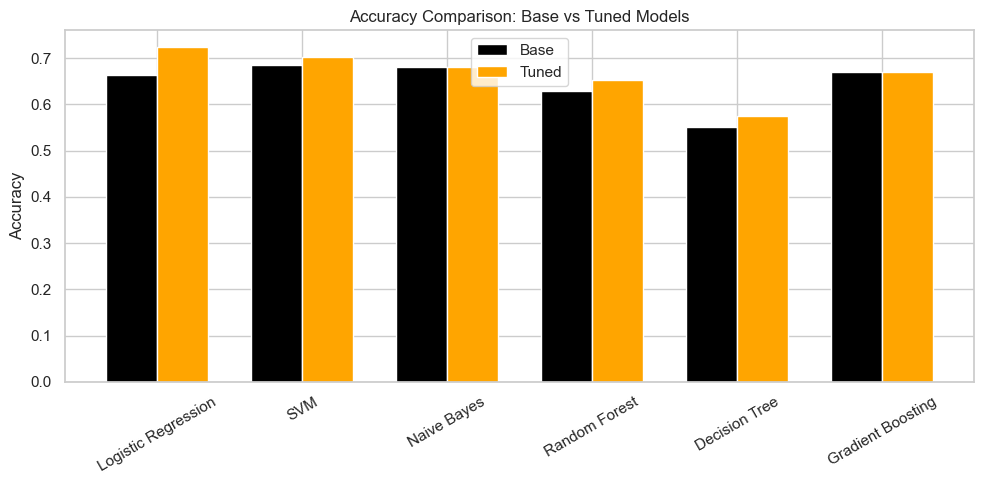

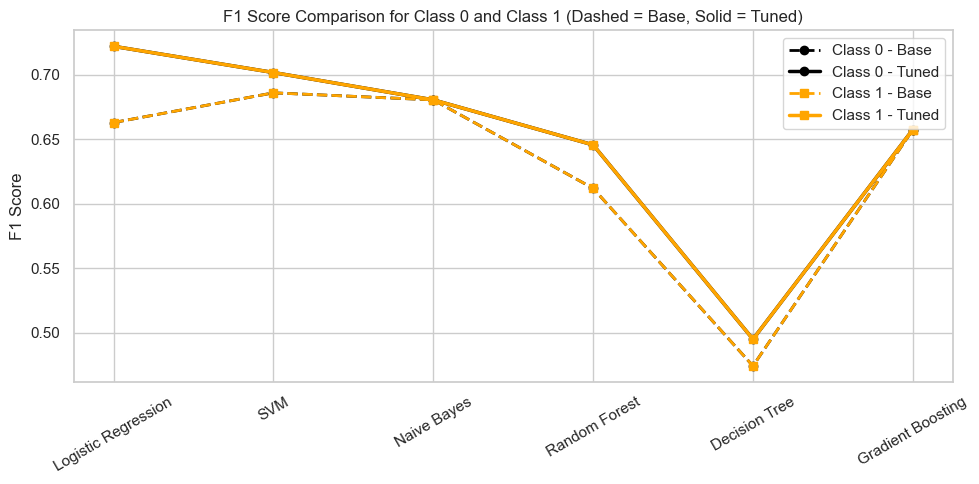

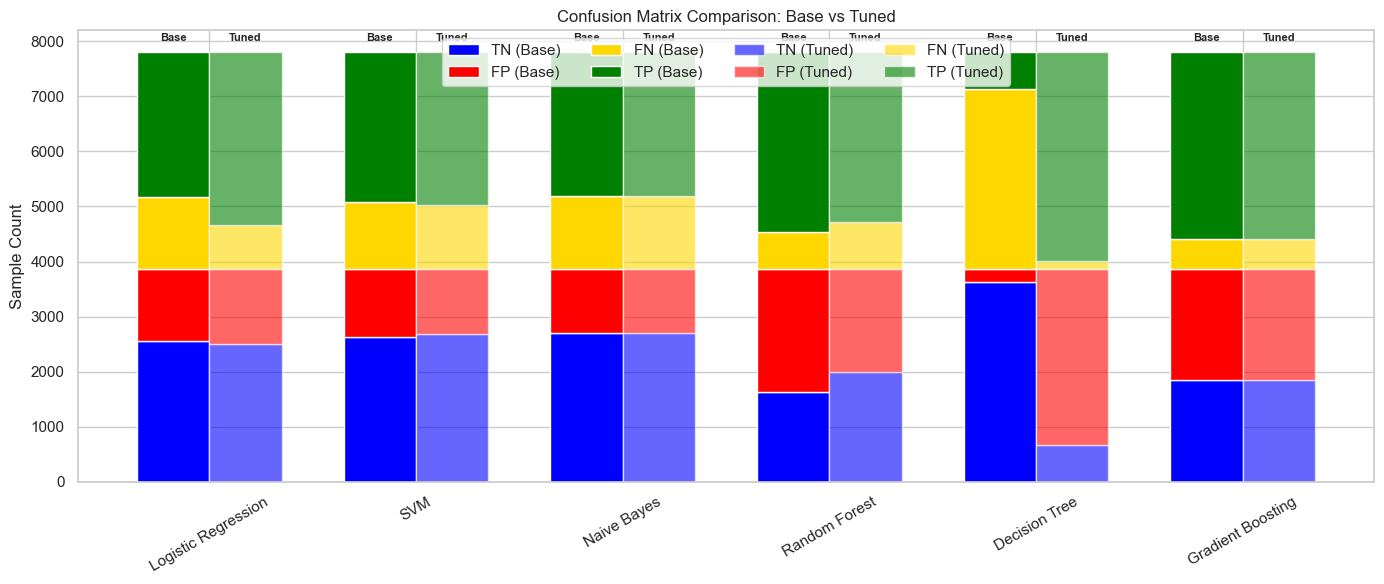

In [270]:

models = base_results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, base_results_df['Accuracy'], width, label='Base', color='black')
plt.bar(x + width/2, tuned_results_df['Accuracy'], width, label='Tuned', color='orange')
plt.xticks(x, models, rotation=30)
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Base vs Tuned Models')
plt.legend()
plt.tight_layout()
plt.show()

# F1 Score 
plt.figure(figsize=(10, 5))

plt.plot(models, base_results_df['F1-Score Class 0'], linestyle='--', marker='o',label='Class 0 - Base', color='black', linewidth=2)
plt.plot(models, tuned_results_df['F1-Score Class 0'], linestyle='-', marker='o',label='Class 0 - Tuned', color='black', linewidth=2.5)
plt.plot(models, base_results_df['F1-Score Class 1'], linestyle='--', marker='s',label='Class 1 - Base', color='orange', linewidth=2)
plt.plot(models, tuned_results_df['F1-Score Class 1'], linestyle='-', marker='s',label='Class 1 - Tuned', color='orange', linewidth=2.5)
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison for Class 0 and Class 1 (Dashed = Base, Solid = Tuned)')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

#Confusion Matrix 
fig, ax = plt.subplots(figsize=(14, 6))
width = 0.35

bar_base_TN = ax.bar(x - width/2, base_TN, width, label='TN (Base)', color='blue')
bar_base_FP = ax.bar(x - width/2, base_FP, width, bottom=base_TN, label='FP (Base)', color='red')
bar_base_FN = ax.bar(x - width/2, base_FN, width, bottom=base_TN + base_FP, label='FN (Base)', color='gold')
bar_base_TP = ax.bar(x - width/2, base_TP, width, bottom=base_TN + base_FP + base_FN, label='TP (Base)', color='green')

bar_tuned_TN = ax.bar(x + width/2, tuned_TN, width, label='TN (Tuned)', color='blue', alpha=0.6)
bar_tuned_FP = ax.bar(x + width/2, tuned_FP, width, bottom=tuned_TN, label='FP (Tuned)', color='red', alpha=0.6)
bar_tuned_FN = ax.bar(x + width/2, tuned_FN, width, bottom=tuned_TN + tuned_FP, label='FN (Tuned)', color='gold', alpha=0.6)
bar_tuned_TP = ax.bar(x + width/2, tuned_TP, width, bottom=tuned_TN + tuned_FP + tuned_FN, label='TP (Tuned)', color='green', alpha=0.6)

for i in range(len(models)):
    base_total = base_TN[i] + base_FP[i] + base_FN[i] + base_TP[i]
    tuned_total = tuned_TN[i] + tuned_FP[i] + tuned_FN[i] + tuned_TP[i]
    ax.text(x[i] - width/2, base_total + 200, 'Base', ha='center', fontsize=8, fontweight='bold')
    ax.text(x[i] + width/2, tuned_total + 200, 'Tuned', ha='center', fontsize=8, fontweight='bold')

ax.set_ylabel("Sample Count")
ax.set_title("Confusion Matrix Comparison: Base vs Tuned")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30)
ax.legend(loc='upper center', ncol=4)
plt.tight_layout()
plt.show()



In [271]:
print("\nBASE MODEL RESULTS")
print(base_results_df[['Model', 'Accuracy', 'F1-Score Class 0', 'F1-Score Class 1']])
print(base_results_df[['Confusion Matrix (0, 0)', 'Confusion Matrix (0, 1)', 'Confusion Matrix (1, 0)', 'Confusion Matrix (1, 1)']])

print("\nTUNED MODEL RESULTS")
print(tuned_results_df[['Model', 'Accuracy', 'F1-Score Class 0', 'F1-Score Class 1']])
print(tuned_results_df[['Confusion Matrix (0, 0)', 'Confusion Matrix (0, 1)', 'Confusion Matrix (1, 0)', 'Confusion Matrix (1, 1)']])



=== BASE MODEL RESULTS ===
                 Model  Accuracy  F1-Score Class 0  F1-Score Class 1
0  Logistic Regression  0.662993          0.662994          0.662994
1                  SVM  0.686058          0.686055          0.686055
2          Naive Bayes  0.680677          0.680600          0.680600
3        Random Forest  0.628011          0.611961          0.611961
4        Decision Tree  0.551640          0.474132          0.474132
5    Gradient Boosting  0.670297          0.657527          0.657527
   Confusion Matrix (0, 0)  Confusion Matrix (0, 1)  Confusion Matrix (1, 0)  \
0                     2549                     1314                     1316   
1                     2634                     1229                     1221   
2                     2700                     1163                     1329   
3                     1638                     2225                      678   
4                     3634                      229                     3270   
5        